In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, AdaBoostClassifier, AdaBoostRegressor
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('D:\\New folder\\Housing.csv')


In [3]:

# Preprocessing: Encoding categorical columns
label_encoder = LabelEncoder()
data['mainroad'] = label_encoder.fit_transform(data['mainroad'])
data['guestroom'] = label_encoder.fit_transform(data['guestroom'])
data['basement'] = label_encoder.fit_transform(data['basement'])
data['hotwaterheating'] = label_encoder.fit_transform(data['hotwaterheating'])
data['airconditioning'] = label_encoder.fit_transform(data['airconditioning'])
data['prefarea'] = label_encoder.fit_transform(data['prefarea'])
data['furnishingstatus'] = label_encoder.fit_transform(data['furnishingstatus'])

# Separate features and target variable
X = data.drop('price', axis=1)  # Features
y = data['price']  # Target variable (price)

# Split into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
# Initialize and train the Decision Tree model
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, y_train)

# Make predictions on training and test sets
y_train_pred = dt_regressor.predict(X_train)
y_test_pred = dt_regressor.predict(X_test)

# Evaluate the model using Mean Squared Error (MSE)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Training MSE: {train_mse}")
print(f"Testing MSE: {test_mse}")


Training MSE: 4500863532.110092
Testing MSE: 2688177649082.569


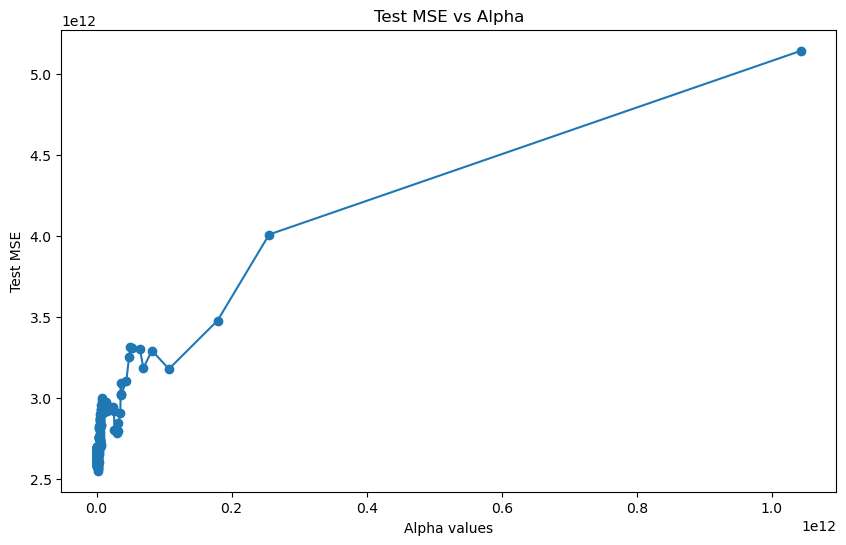

In [5]:
# Get the effective alpha values for pruning
path = dt_regressor.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Train multiple models with different alpha values
trees = []
for ccp_alpha in ccp_alphas:
    tree = DecisionTreeRegressor(random_state=42, ccp_alpha=ccp_alpha)
    tree.fit(X_train, y_train)
    trees.append(tree)

# Select the tree with the best alpha (smallest test MSE)
tree_mse = []
for tree in trees:
    y_pred = tree.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    tree_mse.append(mse)

# Plot the test MSE vs alpha values
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, tree_mse, marker='o')
plt.xlabel('Alpha values')
plt.ylabel('Test MSE')
plt.title('Test MSE vs Alpha')
plt.show()

# Get the optimal tree
best_tree = trees[tree_mse.index(min(tree_mse))]


[Text(0.6727471315510452, 0.9761904761904762, 'x[0] <= 5992.5\nsquared_error = 3083392377710.133\nsamples = 436\nvalue = 4706527.385'),
 Text(0.4648425666464708, 0.9285714285714286, 'x[2] <= 1.5\nsquared_error = 1418016137001.135\nsamples = 294\nvalue = 3996595.238'),
 Text(0.31400049227506815, 0.8809523809523809, 'x[11] <= 1.5\nsquared_error = 947865605059.252\nsamples = 242\nvalue = 3757698.347'),
 Text(0.1631039836413208, 0.8333333333333334, 'x[0] <= 3505.0\nsquared_error = 819362425512.291\nsamples = 146\nvalue = 4069085.616'),
 Text(0.06376855498333839, 0.7857142857142857, 'x[4] <= 0.5\nsquared_error = 563969718900.0\nsamples = 50\nvalue = 3567200.0'),
 Text(0.019993941229930322, 0.7380952380952381, 'x[3] <= 1.5\nsquared_error = 324572936955.557\nsamples = 15\nvalue = 3024676.667'),
 Text(0.00969403211148137, 0.6904761904761905, 'x[0] <= 2520.0\nsquared_error = 254474659600.0\nsamples = 5\nvalue = 2593430.0'),
 Text(0.004847016055740685, 0.6428571428571429, 'x[0] <= 2118.0\nsquare

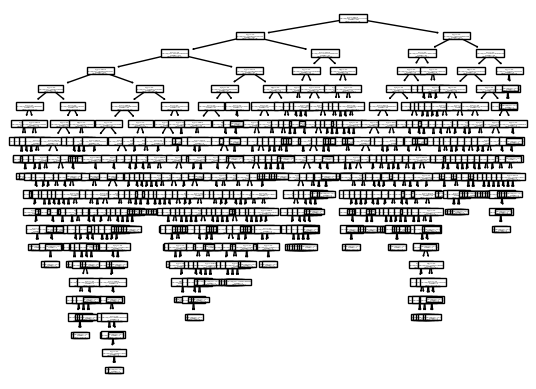

In [12]:
plot_tree(dt_regressor)

In [7]:
# Train a Random Forest regressor
rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(X_train, y_train)

# Evaluate the Random Forest model
rf_train_mse = mean_squared_error(y_train, rf_regressor.predict(X_train))
rf_test_mse = mean_squared_error(y_test, rf_regressor.predict(X_test))

print(f"Random Forest Training MSE: {rf_train_mse}")
print(f"Random Forest Testing MSE: {rf_test_mse}")


Random Forest Training MSE: 157861589321.27084
Random Forest Testing MSE: 1963538216518.6526


In [8]:
# AdaBoost with Decision Stumps (shallow trees)
dt_stump = DecisionTreeClassifier(max_depth=1, random_state=42)
ada_boost = AdaBoostClassifier(base_estimator=dt_stump, n_estimators=50, random_state=42)
ada_boost.fit(X_train, y_train)

# Evaluate the AdaBoost model
y_train_pred_ada = ada_boost.predict(X_train)
y_test_pred_ada = ada_boost.predict(X_test)

# Accuracy for classification task (if target is categorical)
train_accuracy = accuracy_score(y_train, y_train_pred_ada)
test_accuracy = accuracy_score(y_test, y_test_pred_ada)

print(f"AdaBoost Training Accuracy: {train_accuracy}")
print(f"AdaBoost Testing Accuracy: {test_accuracy}")


AdaBoost Training Accuracy: 0.0481651376146789
AdaBoost Testing Accuracy: 0.009174311926605505


c:\Users\Student\anaconda3\Lib\site-packages\sklearn\ensemble\_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


In [ ]:
plot_tree